In [1]:
import os 
import rosalia as rs
import pandas as pd
import ephessos as ep
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

plt.style.use(os.path.dirname(rs.__file__) + "/style/presi_style.mplstyle")

100%|██████████| 1/1 [00:00<00:00,  2.08it/s]


Hey! plot_footprint
Finding ra dec constraints
Getting detector corners
Plotting...


100%|██████████| 1/1 [00:00<00:00, 258.02it/s]


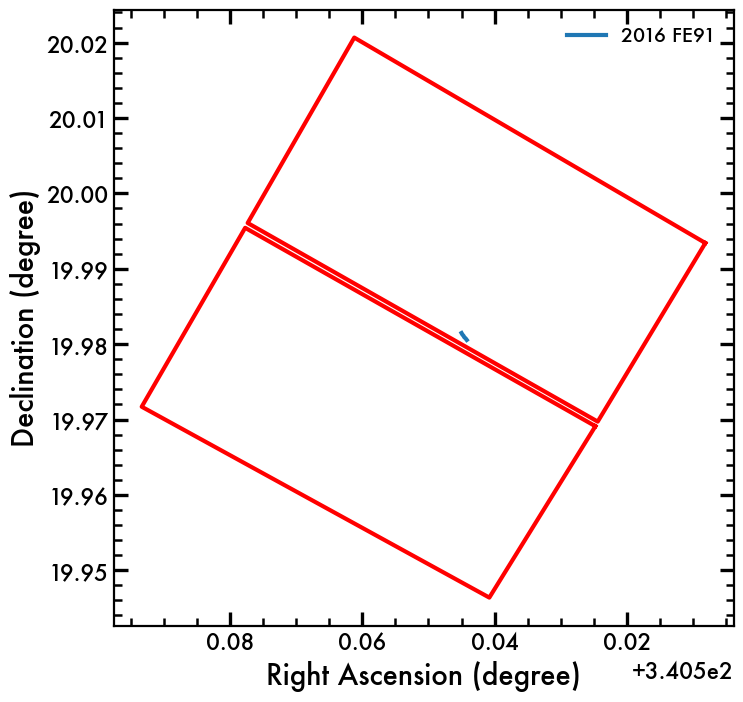

In [2]:
# filename="/Users/aborlaff/NASA/AURELIEN/UFO/MAST_2022-05-05T1554/HST/ic1601hsq/ic1601hsq_flt.fits"
# hst_exp = exposure(filename="/Users/aborlaff/NASA/AURELIEN/UFO/MAST_2022-05-05T1554/HST/ic1601hsq/ic1601hsq_flt.fits")
import rosalia as rs 
filename = "/Users/aborlaff/Downloads/MAST_2026-05-08T2317/HST/j90za9qmq/j90za9qmq_flc.fits"
hst_exp = rs.core.exposure(filename=filename)
hst_exp.FPA_NEAR_RADIUS = hst_exp.FPA_NEAR_RADIUS
# print(hst_exp.FPA_NEAR_RADIUS)
cone_search, ephessos_df = hst_exp.get_nearby_ssos(time_step="1m")

from tqdm import tqdm

ax = hst_exp.plot_footprint()
for i in tqdm(range(len(ephessos_df))):
    # print(ephessos_df[i]["Designation"][0])
    ax.plot(ephessos_df[i]["RA_deg_ICRF"], ephessos_df[i]["DEC_deg_ICRF"], label=ephessos_df[i]["Designation"].iloc[0])
    ax.legend(frameon=False)
ax.xaxis.set_inverted(True) 
plt.savefig("j90za9qmq_flc_ephessos.png", dpi=300)
plt.show()


SyntaxError: invalid syntax (3250991972.py, line 17)

In [ ]:
RA_TARG = 100
DEC_TARG = 23
FILTER = "F106"
PA_Y = 30
EXPSTART = 61000
EXPTIME = 600
observer={"TELESCOP": "Roman/WFI", "pointing": [RA_TARG, DEC_TARG], "FILTER":FILTER, "PA_Y": PA_Y, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

print("pointing" in observer)

custom_roman_exposure = rs.core.exposure(observer=observer) # rs.core.exposure(telescope=telescope)



In [ ]:
custom_roman_exposure

In [ ]:
self = custom_exposure
self.XYZ_HELIO_POS


In [ ]:
target_name = ep.core.jpl_name_translation("Moon")
reference_name = ep.core.jpl_name_translation("Earth")

print(ep.core.ephessos(designation=target_name, obs_center=reference_name, mode="VECTORS", mjd_start=61000, mjd_end=61001))

In [ ]:
TELESCOP = "STARFOX"
INSTRUME = "STARFOX"
DETECTOR = "STARFOX"
RA_TARG = 100
DEC_TARG = 23
PA_Y = 32
NAXIS1=3048
NAXIS2=4096
PIXSCALE=8/60/60
R_mirror=1
OBSLOC=273
EXPSTART=61000
EXPTIME=10
FILTER_PARAMS={"NAME": "F606W", "TELESCOPE": "HST", "INSTRUMENT": "ACS", "DETECTOR": "WFC"}

telescope = {"TELESCOP":TELESCOP, "INSTRUME":INSTRUME, "DETECTOR": DETECTOR,
             "pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "DATA_SHAPE": [NAXIS1, NAXIS2], "PIXSCALE": PIXSCALE,
             "R_mirror": R_mirror, "FILTER_PARAMS":FILTER_PARAMS, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

custom_exposure = rs.core.exposure(telescope=telescope)
custom_exposure.get_detector_corners()
custom_exposure.plot_footprint()
custom_exposure.ASTROPYWCS[0].proj_plane_pixel_scales()

custom_exposure.make_dummy()

In [ ]:
self = custom_exposure

if True:
    if True:
        step = 100
        grid_method="random"
    # def make_zodiacal(self, step=100):

        for w in self.ASTROPYWCS:
            detector_grid = rs.detectors.make_detector_grid(w=w, step=step, mode=grid_method)
    
            # Zodipy queries must go in um so we need to multiply by 1E+7 the m above
            obspos = np.array([exposure_identity["XYZ_HELIO_POS"][0][0].value,
                               exposure_identity["XYZ_HELIO_POS"][1][0].value,
                               exposure_identity["XYZ_HELIO_POS"][2][0].value])*u.AU

            zody_MJysr = zodipy_zody(ra=detector_grid["grid_world"][0],
                                     dec=detector_grid["grid_world"][1],
                                     wavelength=rebinned_wavelength.to("um").value,
                                     weights=rebinned_transmission,
                                     expstart=expstart,
                                     obspos=obspos)


In [ ]:
ep.core.ephessos(designation="")

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
filename = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269.fits"

artemis_fits = fits.open(filename)
# plt.imshow(np.flip(artemis_fits[0].data[1,:,:], axis=0))
artemis_fits[0].header

In [ ]:
hst_exp.PIXSCALE.to("arcsec")

In [ ]:
# Try the Artemis image 
import rosalia as rs
# Fix the flip in the Y-axis
filename = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269.fits"
artemis_fits = fits.open(filename)
#artemis_fits[0].data = np.flip(artemis_fits[0].data[1,:,:], axis=0)
#artemis_fits[0].header["CD1_1"] = -artemis_fits[0].header["CD1_1"]
#artemis_fits[0].header["CD1_2"] = -artemis_fits[0].header["CD1_2"]
#artemis_fits[0].header["CD2_1"] = -artemis_fits[0].header["CD2_1"]
#artemis_fits[0].header["CD2_2"] = -artemis_fits[0].header["CD2_2"]
artemis_fits.verify("silentfix")
fixed_artemis_name = filename.replace(".fits", "_fix.fits")
artemis_fits.writeto(fixed_artemis_name, overwrite=True)

rs.utils.run_swarp(pattern=fixed_artemis_name, outname="/Users/aborlaff/NASA/LUNARIS/ART002-E-28269_aligned.fits", resample=False)
filename = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269_aligned.fits"
filename_cal = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269_aligned_cal.fits"

# Fix the header so it is taken by ROSALIA
from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS

artemis_fits = fits.open(filename)
artemis_fits[0].data = artemis_fits[0].data[:,:]
wcs = WCS(header=artemis_fits[0], fobj=artemis_fits, naxis=2)

artemis_fits[0].header["EXPSTART"] = Time('2026-04-07T21:31:40.000', scale="utc").mjd # ISOT FORMAT: '2004-09-15T21:59:21.929'
artemis_fits[0].header["EXPTIME"] = 600
artemis_fits[0].header["BUNIT"] = "cps"
artemis_fits[0].header["TELESCOP"] = "ARTEMIS-II"
artemis_fits[0].header["FILTER"] = "g"
artemis_fits[0].header["INSTRUME"] = "SDSS"
artemis_fits[0].header["DETECTOR"] = "SDSS"
artemis_fits[0].header["EXTNAME"] = "SCI"
#artemis_fits[0].header["PA"] = -6.8


artemis_fits.verify("silentfix")
artemis_fits.writeto(filename_cal, overwrite=True)

artemis_exp = exposure(filename=filename_cal)


In [ ]:
cone_search, ephessos_df = artemis_exp.get_nearby_ssos(time_step="1m")

import matplotlib.pyplot as plt
from tqdm import tqdm

artemis_exp.plot_footprint()
xy_ssos = []

canvas = fits.open(filename_cal)
canvas[0].data = np.zeros(canvas[0].data.shape)
import copy 
for i in tqdm(range(len(ephessos_df))):
    # print(ephessos_df[i]["Designation"][0])
    plt.plot(ephessos_df[i]["RA_deg_ICRF"],
             ephessos_df[i]["DEC_deg_ICRF"],
             label=ephessos_df[i]["Designation"].iloc[0], linewidth=5)
    plt.legend(frameon=False)

    xy = rs.utils.radec_to_xy(ra=ephessos_df[i]["RA_deg_ICRF"], dec=ephessos_df[i]["DEC_deg_ICRF"], fits_name=filename_cal, ext=0)
    # print(xy)
    xy_ssos.append(xy)
    try:
        canvas[0].data[np.array(xy[0], dtype="int32"),np.array(xy[1], dtype="int32")] = i
    except:
        print("Out of bonds")
canvas.verify("silentfix")
canvas.writeto("artemis_sats_mask.fits", overwrite=True)


In [ ]:
plt.plot(ephessos_df[i]["RA_deg_ICRF"],
         ephessos_df[i]["DEC_deg_ICRF"],
         label=ephessos_df[i]["Designation"].iloc[0], linewidth=5)

In [ ]:
artemis_exp.plot_footprint(verbose=True)

In [ ]:
import copy 
self = copy.deepcopy(artemis_exp) 
verbose=True
print("Hey! plot_footprint")
if verbose: print("Finding ra dec constraints")
ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=verbose)
print("test1")
print(ra_dec_constraints)
print("test")

In [ ]:
if False:
    if True:
        self = copy.deepcopy(artemis_exp) 
        verbose=True
        # def plot_footprint(self, verbose=True, ax=None, color='red', label=None):
        print("Hey! plot_footprint")
        if verbose: print("Finding ra dec constraints")
        ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=verbose)
        if verbose: print("Getting detector corners")
        exp_corners = self.get_detector_corners()
        if verbose: print("Plotting...")
        if ax is None:
            fig, ax = plt.subplots(figsize=(8,8))
        for i in range(len(self.SCIEXTS)):
            x = np.array(exp_corners[i]["corners_world"][:,0].tolist() + [exp_corners[i]["corners_world"][0,0]])
            y = np.array(exp_corners[i]["corners_world"][:,1].tolist() + [exp_corners[i]["corners_world"][0,1]])
            ax.plot(x, y, color=color, label=label)
            ax.set_xlim(ra_dec_constraints["ra_max"], ra_dec_constraints["ra_min"])
            ax.set_ylim(ra_dec_constraints["dec_min"], ra_dec_constraints["dec_max"])
            ax.set_xlabel("Right Ascension (degree)")
            ax.set_ylabel("Declination (degree)")
        # return(ax)

In [ ]:
artemis_exp.plot_footprint(verbose=True)

In [ ]:
print(artemis_exp.TELESCOP)

In [ ]:
a = fits.open(filename_cal)
wcs = WCS(a[0], a, naxis=2)
header = wcs.to_header()
print(header)
print("PC1_2" in header)

In [ ]:
type(header)

In [ ]:
header = exposure_identity["ASTROPYWCS"][0].to_header()
import numpy as np

theta_rad = np.arctan2(-header["PC1_2"], header["PC2_2"])

# Convert to degrees
np.degrees(theta_rad)


In [ ]:
header = exposure_identity["ASTROPYWCS"][0].to_header()
header

In [ ]:
artemis_exp = exposure(filename=filename_cal)
artemis_exp.FPA_NEAR_RADIUS = hst_exp.FPA_NEAR_RADIUS
# print(hst_exp.FPA_NEAR_RADIUS)
cone_search, ephessos_df = artemis_exp.get_nearby_ssos(time_step="1m")

import matplotlib.pyplot as plt
from tqdm import tqdm

artemis_exp.plot_footprint()

for i in tqdm(range(len(ephessos_df))):
    # print(ephessos_df[i]["Designation"][0])
    plt.plot(ephessos_df[i]["RA_deg_ICRF"], ephessos_df[i]["DEC_deg_ICRF"], label=ephessos_df[i]["Designation"].iloc[0])
    plt.legend(frameon=False)

In [ ]:
# Parallax calculations 

d_Earth_sun = 149.60E+9 #m
d_Earth_moon = 385000E+3 # m
sphere_moon = 0.0643E+6 # m
r_Earth = 6378E+3 # m 
h_hubble = 550E+3 # m
import numpy as np
parallax = 2*(r_Earth + h_hubble)/d_Earth_sun/np.pi*180*60*60
print(parallax)

In [ ]:
# Parallax calculations 
# One of the trails is about 1000 arcsec long. How fast does that have to be? 
import numpy as np
exptime = 10 # seconds 

parallax = np.tan(1000/60/60/exptime)*d_Earth_sun
print("At 1 AU")
print(str(parallax/1000) + " km/s") 

parallax = 1000/60/60*d_Earth_moon/10
print("At 1 Moon-Earth Distance")
print(str(parallax/1000) + " km/s") 
print(str(60*60*parallax/1000) + " km/h") 


parallax = 1000/60/60*sphere_moon/10
print("At Moon")
print(str(parallax/1000) + " km/s") 
print(str(60*60*parallax/1000) + " km/h") 



In [ ]:
0.0643

In [ ]:
for i in range(len(ssos)):
    print(str(ssos[i]["RA_deg_ICRF"][0]) + " " + str(ssos[i]["DEC_deg_ICRF"][0]))

In [ ]:
from astropy.time import Time
#t1 = Time('2006-01-01', scale="tt")
t1 = Time(hst_exp.EXPSTART, format="mjd", scale="tt")
t2 = Time(hst_exp.EXPEND, format="mjd", scale="tt")
#t2 = Time('2006-01-02', scale="tt")

print(t1.isot)
print(t2.isot)
# print(t.td)

In [ ]:
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND='499'&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@399'&START_TIME='2006-01-01'&STOP_TIME='2006-01-20'&STEP_SIZE='1%20d'&QUANTITIES='1,9,20,23,24,29'

In [ ]:
ssos

In [ ]:
import pympc
pympc.utils.ensure_obs_codes_cached(update=True)

In [ ]:
custom_exposure.get_detector_corners()


In [ ]:
nearby_catalog = custom_exposure.get_nearby_sources()

In [ ]:
# Zodiacal light STScI
# roman_notebooks/notebooks/background_visualization_tool/rbt.py     def read_bkg_data_from_url(self, cache_file, verbose=False):

In [ ]:


TELESCOP="STARFOX"
RA_TARG = 100
DEC_TARG = 23
PA_Y = 32
NAXIS1=2048
NAXIS2=4096
PIXSCALE=8/60/60
R_mirror=1
OBSLOC=273
EXPSTART=61000
EXPTIME=10
FILTER_PARAMS={"NAME": "F606W", "TELESCOPE": "HST", "INSTRUMENT": "ACS", "DETECTOR": "WFC"}

telescope = {"TELESCOP":TELESCOP, "pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "DATA_SHAPE": [NAXIS1, NAXIS2], "PIXSCALE": PIXSCALE,
             "R_mirror": R_mirror, "FILTER_PARAMS":FILTER_PARAMS, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

custom_exposure = exposure(telescope=telescope)
custom_exposure.get_detector_corners()
custom_exposure.plot_footprint()
custom_exposure.ASTROPYWCS[0].proj_plane_pixel_scales()

In [ ]:
import glob
roman_fits = glob.glob("/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI*[0-9].fits")

for i in range(len(roman_fits)):
    print(roman_fits[i])
    roman_exposure = exposure(roman_fits[i])
    roman_exposure.plot_footprint()
    roman_exposure.find_nearby_ssos()

In [ ]:
(/60/60*4096)**2

In [ ]:
# roman_exposure.get_detector_corners()
rs.utils.find_max_angular_size_of_image(wcs=roman_exposure.ASTROPYWCS)    

In [ ]:
ep.core.get_last_mpcorb()

In [ ]:
exp_corners[0]["corners_world"][:,0].tolist()

In [ ]:
import pympc 
pympc.update_catalogue()

In [ ]:
from astropy.coordinates import SkyCoord

from astropy.time import Time

from astroquery.jplhorizons import Horizons
import numpy as np

epoch_start = Time('2026-04-02 01:58:32.3051', scale="tt")
epoch_end   = Time('2026-04-10 23:54:22.857', scale="tt")
epochs = {'start': epoch_start.isot, 'stop': epoch_end.isot, 'step': "1m"}

q = Horizons('2026-069A', location='@399', epochs=epochs)

tab = q.vectors(refplane='earth')
import matplotlib.pyplot as plt
plt.plot(tab["x"], tab["y"])

In [ ]:
from astropy.coordinates import SkyCoord

from astropy.time import Time

from astroquery.jplhorizons import Horizons
import numpy as np

epoch_start = Time('2006-04-02 01:58:32.3051', scale="tt")
epoch_end   = Time('2006-04-10 23:54:22.857', scale="tt")
epochs = {'start': epoch_start.isot, 'stop': epoch_end.isot, 'step': "1m"}

q = Horizons('Hubble', location='@399', epochs=epochs)

tab = q.vectors(refplane='earth')
import matplotlib.pyplot as plt
plt.plot(tab["x"], tab["y"])